Tracy, P. J., Kasper, J. C., Zurbuchen, T. H., Raines, J. M., Shearer, P., & Gilbert, J. (2015). THERMALIZATION OF HEAVY IONS IN THE SOLAR WIND. The Astrophysical Journal, 812(2), 170. https://doi.org/10.1088/0004-637X/812/2/170

In [1]:
from datetime import datetime,timedelta
from cdasws import CdasWs
cdas = CdasWs()

from astropy import units as u
u.set_enabled_aliases({'sec': u.s, '#': u.dimensionless_unscaled})

import spcphys_common_functions as scf
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from scipy.constants import physical_constants

In [ ]:
TIME_RANGE = [datetime(1998, 2, 4), datetime(2011, 8, 22)]

_, proton_data = cdas.get_data(dataset='AC_H2_SWE', variables=['Np', 'Vp', 'Tpr'], time0=TIME_RANGE[0], time1=TIME_RANGE[1])
_, heavy_ion_data = cdas.get_data(dataset='AC_H3_SWI', variables=['nHe2', 'vHe2', 'vthHe2', 'HetoO', 'vO6', 'vthO6'], time0=TIME_RANGE[0], time1=TIME_RANGE[1])

In [12]:
_, heavy_ion_data = cdas.get_data(dataset='AC_H3_SWI', variables=['nHe2', 'vHe2', 'vthHe2', 'HetoO', 'vO6', 'vthO6'], time0=TIME_RANGE[0], time1=TIME_RANGE[1])

In [13]:
proton_time = proton_data['Epoch'].values
heavy_ion_time = heavy_ion_data['Epoch'].values

df_proton = pd.DataFrame({
    'time_proton': proton_time,
    'Np': proton_data['Np'].values,
    'Vp': proton_data['Vp'].values,
    'Tpr': proton_data['Tpr'].values,
    'vthpr': scf.vth_E_T.T_to_vth(proton_data['Tpr'].values * u.K, n=1).to(u.km / u.s).value
}).dropna().sort_values('time_proton').reset_index(drop=True)

df_heavy = pd.DataFrame({
    'time_heavy': heavy_ion_time,
    'nHe2': heavy_ion_data['nHe2'].values,
    'vHe2': heavy_ion_data['vHe2'].values,
    'THe2': scf.vth_E_T.vth_to_T(heavy_ion_data['vthHe2'].values * u.km / u.s, n=1).to(u.K).value,
    'vthHe2': heavy_ion_data['vthHe2'].values,
    'nO6': heavy_ion_data['nHe2'].values / heavy_ion_data['HetoO'].values,
    'vO6': heavy_ion_data['vO6'].values,
    'T_O6': scf.vth_E_T.vth_to_T(heavy_ion_data['vthO6'].values * u.km / u.s, n=1).to(u.K).value,
    'vthO6': heavy_ion_data['vthO6'].values
}).dropna().sort_values('time_heavy').reset_index(drop=True)

df_merged = pd.merge_asof(
    df_proton, df_heavy,
    left_on='time_proton', right_on='time_heavy',
    tolerance=pd.Timedelta('10min'),
    direction='nearest'
).dropna(subset=['time_heavy'])

df_matched = df_merged[['time_proton', 'time_heavy', 'Np', 'Vp', 'Tpr', 'vthpr', 'nHe2', 'vHe2', 'THe2', 'vthHe2', 'nO6', 'vO6', 'T_O6', 'vthO6']].copy()
df_matched['time_diff'] = (df_matched['time_proton'] - df_matched['time_heavy']).abs()
df_matched = df_matched.rename(columns={'time_proton': 'time'})

In [14]:
AcHe2 = scf.coulomb_collisional_age.calc_Ac(
    v_j=df_matched['Vp'].values * u.km / u.s, T_j=df_matched['Tpr'].values * u.K, n_j=df_matched['Np'].values * u.cm ** -3, 
    charge_number_j=1, mass_number_j=1, m_j=physical_constants['proton mass'][0] * u.kg, 
    v_i=df_matched['vHe2'].values * u.km / u.s, T_i=df_matched['THe2'].values * u.K, n_i=df_matched['nHe2'].values * u.cm ** -3, 
    charge_number_i=2, mass_number_i=4, m_i=physical_constants['alpha particle mass'][0] * u.kg, 
    distance=1 * u.au
)

AcO6 = scf.coulomb_collisional_age.calc_Ac(
    v_j=df_matched['Vp'].values * u.km / u.s, T_j=df_matched['Tpr'].values * u.K, n_j=df_matched['Np'].values * u.cm ** -3, 
    charge_number_j=1, mass_number_j=1, m_j=physical_constants['proton mass'][0] * u.kg, 
    v_i=df_matched['vO6'].values * u.km / u.s, T_i=df_matched['T_O6'].values * u.K, n_i=df_matched['nO6'].values * u.cm ** -3, 
    charge_number_i=6, mass_number_i=16, m_i=16 * physical_constants['atomic mass constant'][0] * u.kg, 
    distance=1 * u.au
)

/opt/miniconda3/envs/spcphys-notorch/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


/opt/miniconda3/envs/spcphys-notorch/lib/python3.11/site-packages/spcphys_common_functions/processing/plot_tools.py:611: RuntimeWarning: invalid value encountered in divide
  z_hist /= np.nansum(z_hist, axis=1, keepdims=True)


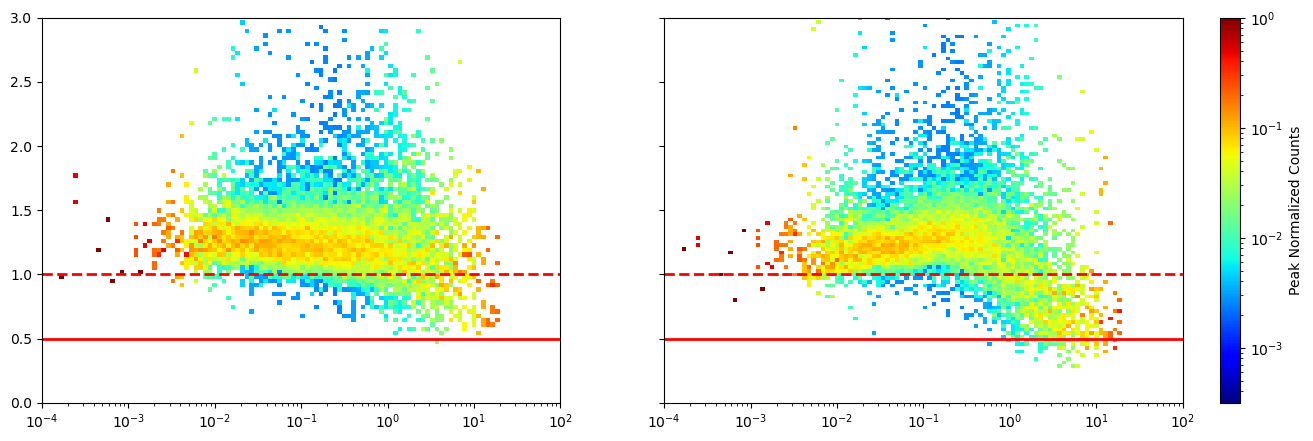

In [15]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(16, 5))

qm = scf.plot_tools.plot_hist2d(
    axes=ax[0], 
    x=AcHe2, 
    y=df_matched['vthHe2'] / df_matched['vthpr'], 
    scales=['log', 'linear'], 
    bins=[100, 200],
    norm_type='sum', 
    color_norm_type='log', 
    color_norm_range=[10**-3.5, 1], 
    separate='x',
    plot_kwargs={
        'cmap': 'jet',
    },
    mid_err_line='x',
    mid_method='median', 
    err_method='iqr',
    mid_err_line_kwargs={
        'color': 'black',
        'linewidth': 2,
    }
)

qm = scf.plot_tools.plot_hist2d(
    axes=ax[1], 
    x=AcHe2, 
    y=df_matched['vthO6'] / df_matched['vthpr'], 
    scales=['log', 'linear'], 
    bins=[100, 200],
    norm_type='sum', 
    color_norm_type='log', 
    color_norm_range=[10**-3.5, 1], 
    separate='x',
    plot_kwargs={
        'cmap': 'jet',
    },
    mid_err_line='x',
    mid_method='median', 
    err_method='iqr',
    mid_err_line_kwargs={
        'color': 'black',
        'linewidth': 2,
    }
)

ax[0].axhline(1, color='red', linestyle='--', linewidth=2)
ax[0].axhline(0.5, color='red', linestyle='-', linewidth=2)
ax[1].axhline(1, color='red', linestyle='--', linewidth=2)
ax[1].axhline(0.5, color='red', linestyle='-', linewidth=2)

ax[0].set_xlim(1e-4, 1e2)
ax[0].set_ylim(0, 3)

plt.colorbar(qm, ax=ax, orientation='vertical', fraction=0.05, pad=0.03, aspect=18.67).set_label('Peak Normalized Counts')